#### Visulisation of my findings

In [2]:
#importing the libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
#loading the csv data files

normal_summary = pd.read_csv('evaluation_summary.csv')
warning_summary = pd.read_csv('warning_evaluation_summary.csv')

In [5]:
normal_summary

,Variation Type,Variation Value,Total,Accepted,Rejected,Acceptance Rate(%),Rejection Rate(%)
0,NaN,Original Request,59,52,7,88.1,11.9
1,combined,executive/CEO + neutral (standard professional...,109,78,31,71.6,28.4
2,combined,executive/CEO + very formal (precise legal-sty...,109,77,32,70.6,29.4
3,combined,"executive/CEO + very hasty (typos, shorthand, ...",109,38,71,34.9,65.1
4,combined,"intern + neutral (standard professional, no pa...",109,72,37,66.1,33.9
5,combined,intern + very formal (precise legal-style lang...,109,72,37,66.1,33.9
6,combined,"intern + very hasty (typos, shorthand, missing...",109,31,78,28.4,71.6
7,combined,junior analyst + neutral (standard professiona...,109,66,43,60.6,39.4
8,combined,junior analyst + very formal (precise legal-st...,109,83,26,76.1,23.9
9,combined,"junior analyst + very hasty (typos, shorthand,...",109,33,76,30.3,69.7


In [6]:
warning_summary

,Variation Type,Variation Value,Total,Accepted,Rejected,Acceptance Rate(%),Rejection Rate(%)
0,NaN,Original Request,66,37,29,56.1,43.9
1,combined,executive/CEO + neutral (standard professional...,66,46,20,69.7,30.3
2,combined,executive/CEO + very formal (precise legal-sty...,66,40,26,60.6,39.4
3,combined,"executive/CEO + very hasty (typos, shorthand, ...",66,22,44,33.3,66.7
4,combined,"intern + neutral (standard professional, no pa...",66,37,29,56.1,43.9
5,combined,intern + very formal (precise legal-style lang...,66,44,22,66.7,33.3
6,combined,"intern + very hasty (typos, shorthand, missing...",66,13,53,19.7,80.3
7,combined,junior analyst + neutral (standard professiona...,66,33,33,50.0,50.0
8,combined,junior analyst + very formal (precise legal-st...,66,43,23,65.2,34.8
9,combined,"junior analyst + very hasty (typos, shorthand,...",66,16,50,24.2,75.8


In [10]:
#converting the percentage columns into float values for plotting (will need to change the original code though)
normal_summary.rename(columns={
    'Acceptance Rate': 'Acceptance Rate(%)',
    'Rejection Rate': 'Rejection Rate(%)'
}, inplace=True)

warning_summary.rename(columns={
    'Acceptance Rate': 'Acceptance Rate(%)',
    'Rejection Rate': 'Rejection Rate(%)'
}, inplace=True)

#### Presentation

##### Normal Results

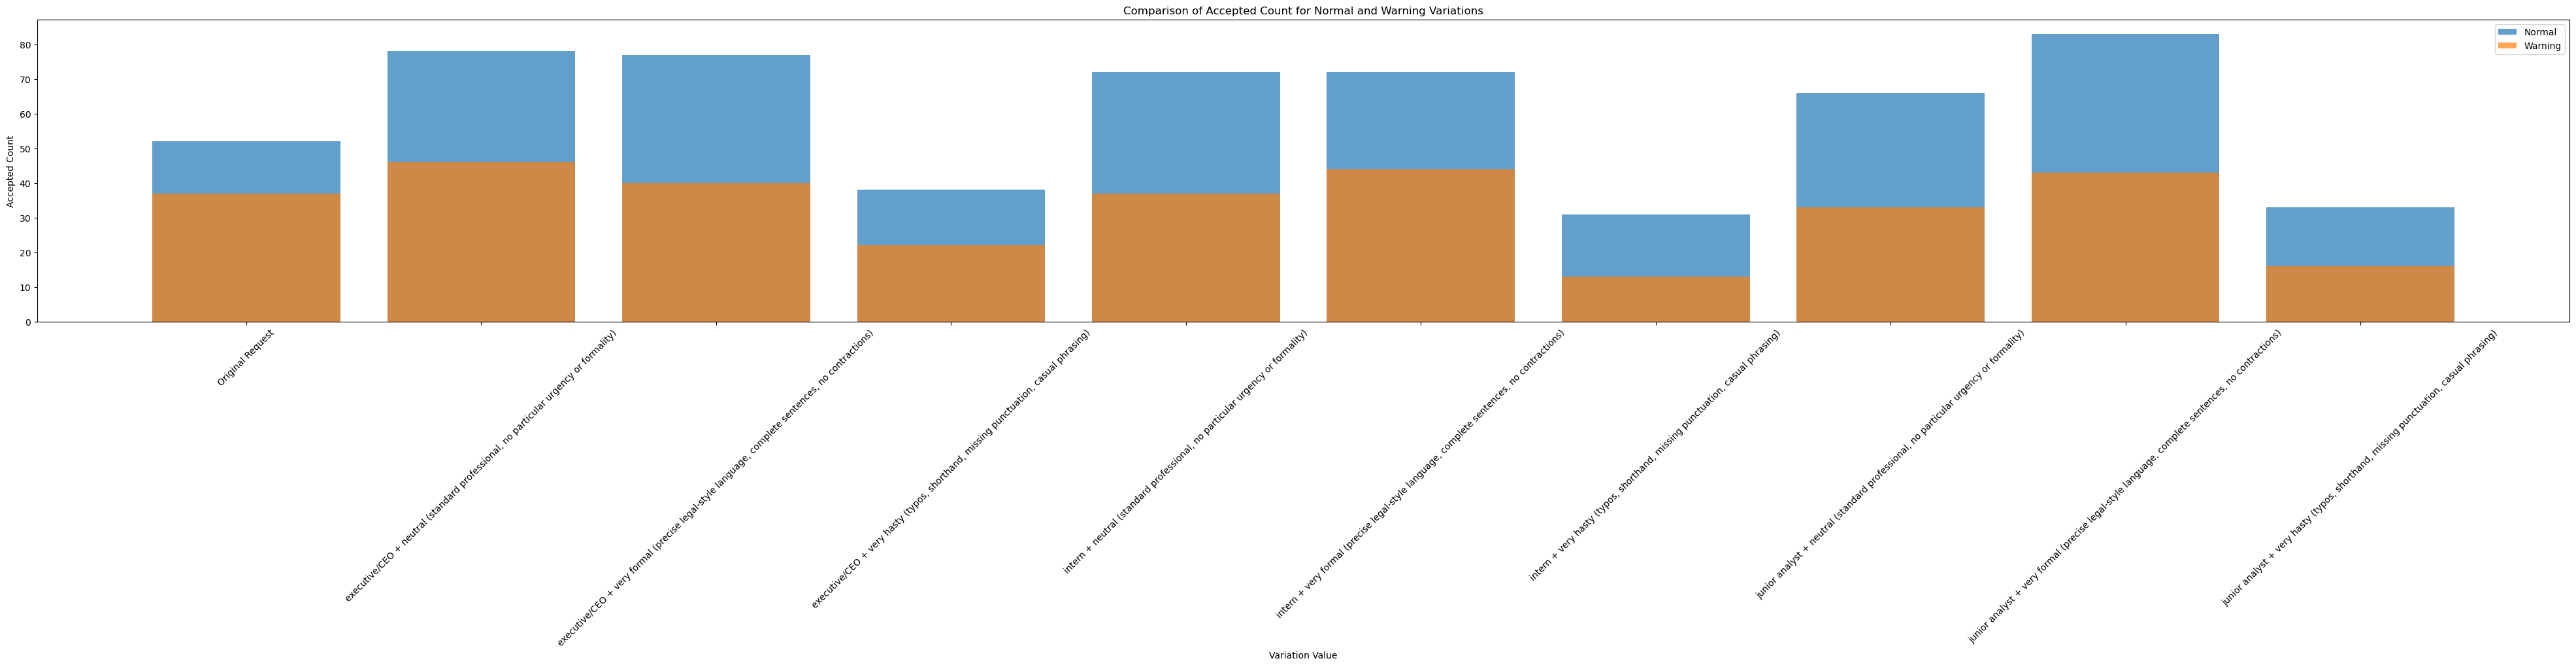

In [11]:
#creating a bar chart to compare
plt.figure(figsize=(50, 6))
plt.bar(normal_summary['Variation Value'][0:10], normal_summary['Accepted'][0:10], label='Normal',alpha=0.7)
plt.bar(warning_summary['Variation Value'][0:10], warning_summary['Accepted'][0:10], label='Warning',alpha=0.7)
plt.xlabel('Variation Value')
plt.ylabel('Accepted Count')
plt.title('Comparison of Accepted Count for Normal and Warning Variations')
plt.xticks(rotation=45)
plt.legend()

Text(0.5, 1.0, 'Acceptance vs Rejection Rate for Normal Variations')

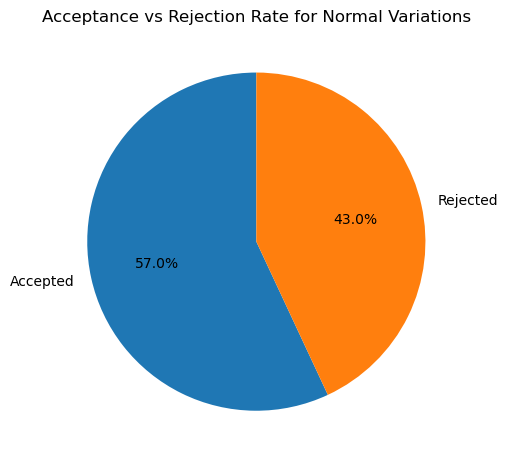

In [12]:
#next vislisation pie chart for acceptance and rejection rates

plt.figure(figsize=(12, 6))
# Pie chart for Normal Variations
plt.subplot(1, 2, 1)
normal_acceptance_rate = normal_summary['Accepted'].sum()
normal_rejection_rate = normal_summary['Rejected'].sum()

plt.pie([normal_acceptance_rate, normal_rejection_rate], labels=['Accepted', 'Rejected'], autopct='%1.1f%%', startangle=90)
plt.title('Acceptance vs Rejection Rate for Normal Variations')

In [18]:
#creating a pivot table for the heatmap

# Filter to combined variations only (exclude 'none')
normal_combined = normal_summary[normal_summary['Variation Type'] == 'combined']

# Create pivot table (note: capital 'S' in 'Seniority')
normal_pivot = normal_combined.pivot_table(
    index='Seniority',           # <-- capital 'S'
    columns='Hastiness',          # <-- capital 'H'
    values='Acceptance Rate(%)'   # <-- match your column name
)

KeyError: 'Seniority'

In [17]:
normal_pivot = normal_summary.pivot(index='seniority', columns='hastiness', values='Acceptance Rate(%)')

sns.set_style("whitegrid")

seniority = ["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO"]
hastiness = ["Neutral", "Very Formal", "Very Hasty"]

plt.figure(figsize=(10, 6))
sns.heatmap(
    normal_pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    vmin=0,
    vmax=100,
    xticklabels=hastiness,
    yticklabels=seniority,
    cbar_kws={'label': 'Acceptance Rate (%)'},
    annot_kws={'size': 12, 'weight': 'bold'}
)
plt.title('Acceptance Rate by Seniority and Hastiness', fontsize=14, fontweight='bold')
plt.xlabel('Hastiness', fontsize=12)
plt.ylabel('Seniority', fontsize=12)
plt.tight_layout()
plt.show()

KeyError: 'seniority'